# Medidas de concentración

Práctica 4 · ENDIREH 2021

**Estado:** configuración inicial; análisis pendiente.

**Objetivo para la siguiente etapa:** Analizar la concentración de casos por entidad con factor de expansión, curva de Lorenz y Gini.

La entrada es el CSV renombrado, generado desde el archivo limpio de la Práctica 3 en `ajuste_columnas_practica_4.ipynb`. Por ahora solo se preparan imports, carga y revisión de columnas.


## 1. Configuración del proyecto

Selecciona el entorno Python `endireh` antes de ejecutar las celdas.


In [32]:
from pathlib import Path
import sys

# Funciona si Jupyter se inicia en la raíz o dentro de notebooks/.
RUTA_PROYECTO = next(
    (ruta for ruta in (Path.cwd(), *Path.cwd().parents)
     if (ruta / "config" / "rutas.py").is_file()),
    None,
)
if RUTA_PROYECTO is None:
    raise FileNotFoundError(
        "No se encontró config/rutas.py. Abre el notebook dentro del proyecto."
    )
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RUTA_PROYECTO))


In [33]:
import polars as pl
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from config.rutas import RUTA_ENDIREH_RENOMBRADO_CSV
from src.statistics.concentracion import (
    coeficiente_gini,
    curva_lorenz,
)

sns.set_theme(style="whitegrid")


## 2. Carga del dataset procesado

Se conserva el CSV original. La validación de columnas no garantiza que los datos estén listos para todos los cálculos.


In [34]:
if not RUTA_ENDIREH_RENOMBRADO_CSV.is_file():
    raise FileNotFoundError(
        f"No se encontró el CSV procesado: {RUTA_ENDIREH_RENOMBRADO_CSV}. "
        "Ejecuta primero notebooks/ajuste_columnas_practica_4.ipynb."
    )

df = pl.read_csv(RUTA_ENDIREH_RENOMBRADO_CSV)

# Solo se valida la estructura básica; no se limpian ni transforman datos.
columnas_requeridas = {
    "cve_entidad", "nom_entidad", "sufrio_violencia_pareja", "factor_expansion"
}
columnas_faltantes = columnas_requeridas.difference(df.columns)
if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas: {sorted(columnas_faltantes)}")

print(f"Archivo: {RUTA_ENDIREH_RENOMBRADO_CSV.name}")
print(f"Filas: {df.height:,} | Columnas: {df.width}")
df.head(5)


Archivo: endireh_2021_renombrado.csv
Filas: 110,127 | Columnas: 24


cve_entidad,nom_entidad,cve_municipio,nom_municipio,anios_sin_convivencia_pareja,tipo_union,tipo_cuestionario,estado_civil_id,estado_civil_desc,estrato_sociodemografico_muestreo,entrevistada_trabaja_id,entrevistada_trabaja_desc,ingreso_laboral_entrevistada,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,hogar_tiene_ahorros_id,hogar_tiene_ahorros_desc,vivienda_propiedad_miembro_hogar_id,vivienda_propiedad_miembro_hogar_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
i64,str,i64,str,i64,i64,str,i64,str,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13,3,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,null,"""C1""",6,"""Soltera""",4,1,"""Sí""",8500.0,1,"""Sí""",2,"""No""",1,"""Sí""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",20,3,"""B1""",2,"""Separada""",2,1,"""Sí""",400.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",1,155,2021


## 3. Variables y ponderación

Para analizar la concentración territorial se utilizan las siguientes variables:

- `nom_entidad`: identifica la entidad federativa.
- `sufrio_violencia_pareja`: indicador binario donde 1 significa que la mujer reportó violencia de pareja y 0 que no la reportó.
- `factor_expansion`: indica cuántas mujeres de la población representa cada observación de la encuesta.

El análisis no se realiza contando únicamente las filas del dataset, ya que la ENDIREH utiliza un diseño muestral. Por ello, los casos de violencia se ponderan mediante el factor de expansión.

Para cada registro se define:

casos ponderados = sufrio_violencia_pareja × factor_expansion

Posteriormente, estos casos se agregan por entidad federativa.


In [35]:
columnas_concentracion = [
    "cve_entidad",
    "nom_entidad",
    "sufrio_violencia_pareja",
    "factor_expansion",
]

base_concentracion = df.select(columnas_concentracion)

print(f"Filas utilizadas: {base_concentracion.height:,}")
print(
    "Número de entidades:",
    base_concentracion["nom_entidad"].n_unique()
)

base_concentracion = base_concentracion.with_columns(
    (
        pl.col("sufrio_violencia_pareja")
        * pl.col("factor_expansion")
    ).alias("casos_ponderados")
)

base_concentracion.head()

Filas utilizadas: 110,127
Número de entidades: 32


cve_entidad,nom_entidad,sufrio_violencia_pareja,factor_expansion,casos_ponderados
i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",0,113,0
1,"""AGUASCALIENTES""",1,113,113
1,"""AGUASCALIENTES""",0,227,0
1,"""AGUASCALIENTES""",0,113,0
1,"""AGUASCALIENTES""",1,155,155


In [36]:
valores_violencia = (
    base_concentracion
    .select("sufrio_violencia_pareja")
    .unique()
    .sort("sufrio_violencia_pareja")
)

valores_violencia

sufrio_violencia_pareja
i64
0
1


In [44]:
por_entidad = (
    base_concentracion
    .group_by([
        "cve_entidad",
        "nom_entidad",
    ])
    .agg([
        pl.col("casos_ponderados")
        .sum()
        .alias("casos_ponderados"),

        pl.col("factor_expansion")
        .sum()
        .alias("poblacion_ponderada"),

        pl.len()
        .alias("n_muestra"),
    ])
    .sort("cve_entidad")
)

# prevalencia ponderada : qué porcentaje de la población representada reporto violencia
por_entidad = por_entidad.with_columns(
    (
        100
        * pl.col("casos_ponderados")
        / pl.col("poblacion_ponderada")
    ).alias("prevalencia_ponderada_pct")
)

por_entidad

cve_entidad,nom_entidad,casos_ponderados,poblacion_ponderada,n_muestra,prevalencia_ponderada_pct
i64,str,i64,i64,u32,f64
1,"""AGUASCALIENTES""",114412,572313,3536,19.991159
2,"""BAJA CALIFORNIA""",163045,1436897,3226,11.347021
3,"""BAJA CALIFORNIA SUR""",43493,311635,3111,13.956391
4,"""CAMPECHE""",56085,363306,3557,15.4374
5,"""COAHUILA DE ZARAGOZA""",215333,1228901,3462,17.522404
…,…,…,…,…,…
28,"""TAMAULIPAS""",199754,1386949,3259,14.402404
29,"""TLAXCALA""",98932,539064,3714,18.352552
30,"""VERACRUZ DE IGNACIO DE LA LLAV…",628188,3316771,3377,18.939746


In [38]:
total_casos = por_entidad["casos_ponderados"].sum()
total_poblacion = por_entidad["poblacion_ponderada"].sum()

prevalencia_nacional = (
    100
    * total_casos
    / total_poblacion
)

print(
    f"Casos ponderados nacionales: "
    f"{total_casos:,.0f}"
)

print(
    f"Población ponderada: "
    f"{total_poblacion:,.0f}"
)

print(
    f"Prevalencia ponderada nacional: "
    f"{prevalencia_nacional:.2f}%"
)

Casos ponderados nacionales: 8,803,573
Población ponderada: 50,523,469
Prevalencia ponderada nacional: 17.42%


## 4. Medidas de concentración

La concentración territorial de los casos ponderados se evalúa mediante el coeficiente de Gini y la curva de Lorenz.

El coeficiente de Gini toma valores cercanos a 0 cuando la distribución de los casos entre las entidades es relativamente uniforme. Conforme el valor aumenta, existe una mayor concentración de los casos en un subconjunto de entidades.

La curva de Lorenz representa en el eje horizontal la proporción acumulada de entidades, ordenadas desde la que presenta menos casos hasta la que presenta más casos, y en el eje vertical la proporción acumulada de casos ponderados.

La diagonal representa una distribución perfectamente uniforme

In [50]:
casos_por_entidad = (
    por_entidad["casos_ponderados"]
    .to_numpy()
)

gini_territorial = coeficiente_gini(casos_por_entidad)

print(
    f"Coeficiente de Gini territorial: "
    f"{gini_territorial}"
)

Coeficiente de Gini territorial: 0.41781981943581314


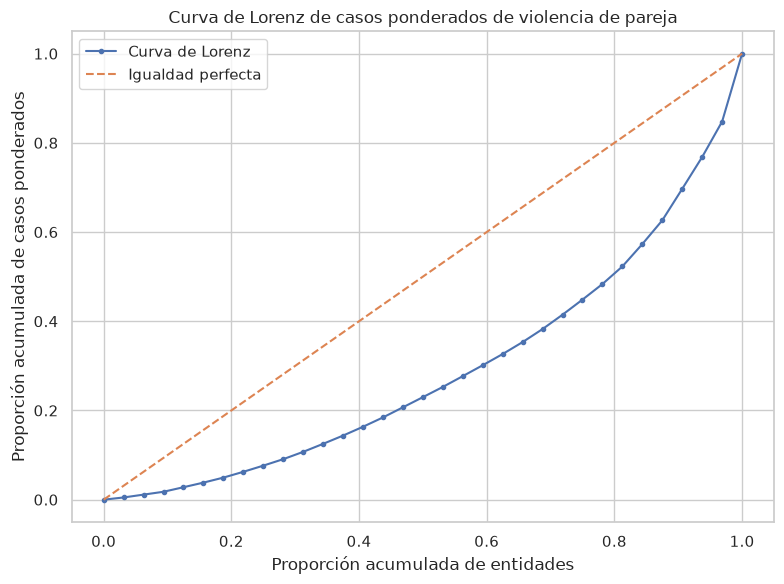

In [41]:
x_lorenz, y_lorenz = curva_lorenz(
    casos_por_entidad
)

plt.figure(figsize=(8, 6))

plt.plot(
    x_lorenz,
    y_lorenz,
    marker="o",
    markersize=3,
    label="Curva de Lorenz",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Igualdad perfecta",
)

plt.xlabel(
    "Proporción acumulada de entidades"
)

plt.ylabel(
    "Proporción acumulada de casos ponderados"
)

plt.title(
    "Curva de Lorenz de casos ponderados "
    "de violencia de pareja"
)

plt.legend()

plt.tight_layout()

plt.show()

La curva de Lorenz se encuentra por debajo de la línea de igualdad perfecta, lo que muestra que los casos ponderados de violencia de pareja no se distribuyen de manera uniforme entre las 32 entidades federativas.

El coeficiente de Gini es de 0.4178, esto indica que existe una concentración territorial apreciable de los casos: algunas entidades reúnen una proporción mayor del total nacional que otras.

Pero este resultado describe la concentración de los casos absolutos ponderados, por lo que también refleja diferencias en el tamaño poblacional de las entidades. Por esto, el análisis se complementa con la prevalencia ponderada por entidad.

## 5. Tablas y visualizaciones

Se comparan dos perspectivas territoriales:

1. El numero absoluto de casos ponderados.
2. La prevalencia ponderada dentro de cada entidad.


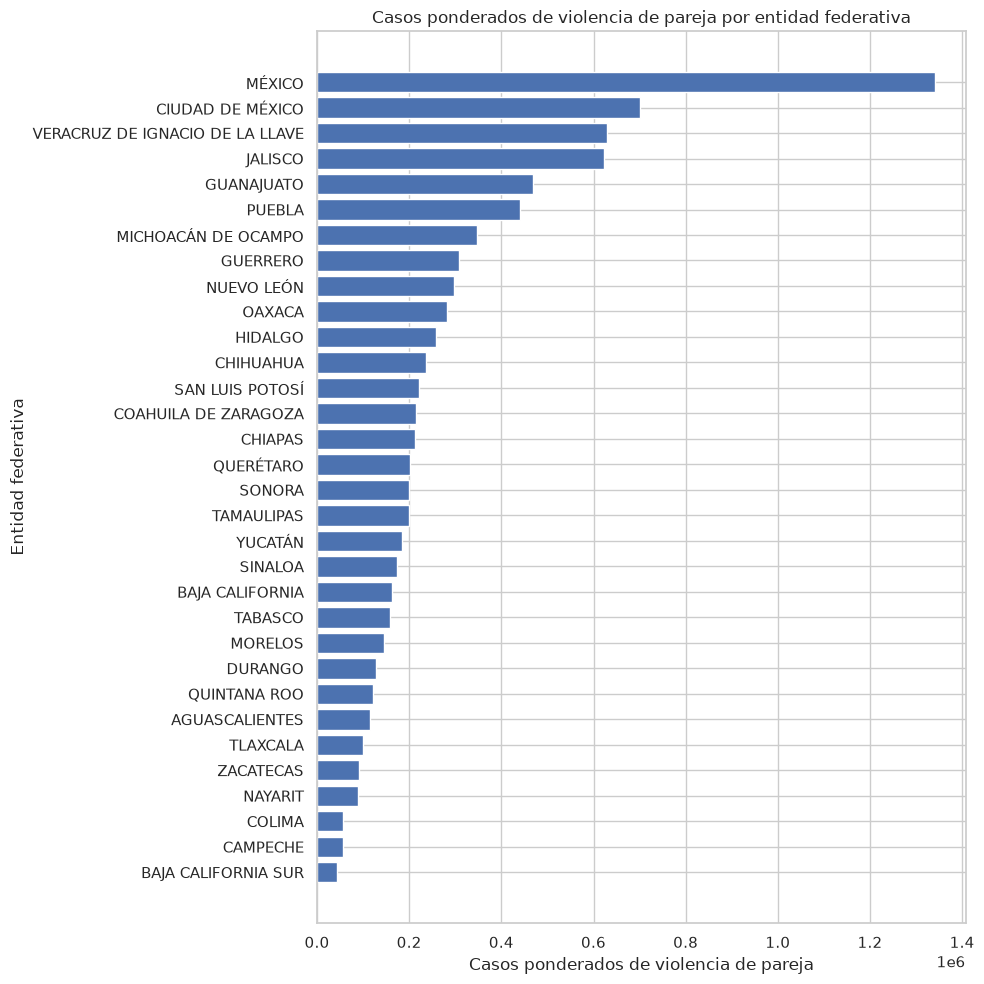

In [46]:
ranking_casos = por_entidad.sort(
    "casos_ponderados"
)

plt.figure(figsize=(10, 10))

plt.barh(
    ranking_casos["nom_entidad"].to_list(),
    ranking_casos["casos_ponderados"].to_list(),
)

plt.xlabel(
    "Casos ponderados de violencia de pareja"
)

plt.ylabel(
    "Entidad federativa"
)

plt.title(
    "Casos ponderados de violencia de pareja "
    "por entidad federativa"
)

plt.tight_layout()

plt.show()

El numero absoluto de casos ponderados varía considerablemente entre entidades. Las entidades situadas en los primeros lugares acumulan una mayor cantidad estimada de mujeres que reportaron violencia de pareja.

Pero esto varia obviamente por la poblacion que tiene cada uno, por lo que con mayor poblacion tiene mayor posibilidad de acumular casos absolutos.

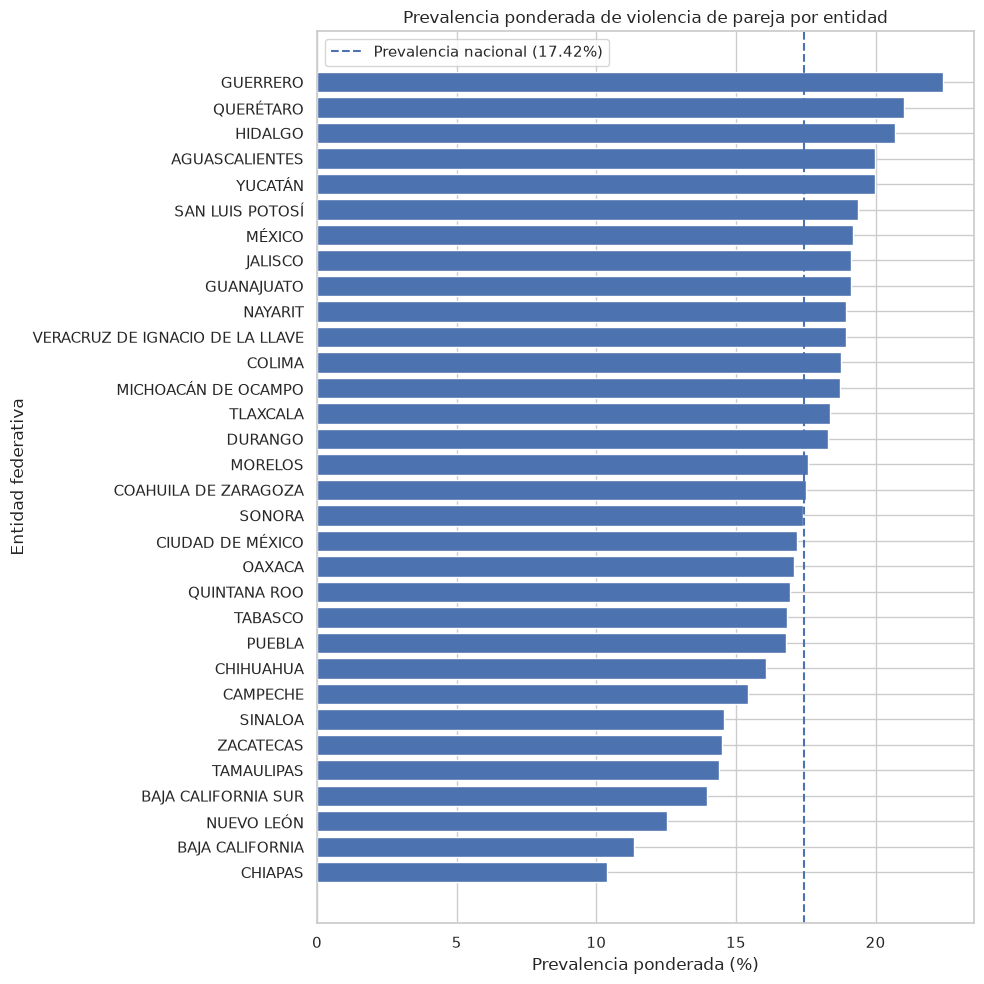

In [47]:
ranking_prevalencia = por_entidad.sort(
    "prevalencia_ponderada_pct"
)

plt.figure(figsize=(10, 10))

plt.barh(
    ranking_prevalencia[
        "nom_entidad"
    ].to_list(),
    ranking_prevalencia[
        "prevalencia_ponderada_pct"
    ].to_list(),
)

plt.axvline(
    prevalencia_nacional,
    linestyle="--",
    label=(
        f"Prevalencia nacional "
        f"({prevalencia_nacional:.2f}%)"
    ),
)

plt.xlabel(
    "Prevalencia ponderada (%)"
)

plt.ylabel(
    "Entidad federativa"
)

plt.title(
    "Prevalencia ponderada de violencia "
    "de pareja por entidad"
)

plt.legend()

plt.tight_layout()

plt.show()

La prevalencia ponderada permite comparar la proporción estimada de mujeres que reportaron violencia de pareja dentro de cada entidad, considerando el factor de expansión de la encuesta.

La línea vertical es la prevalencia ponderada nacional.

## 6. Limitaciones

- El coeficiente de Gini territorial se calcula sobre casos absolutos ponderados, por lo que está influido por las diferencias de tamaño poblacional entre entidades.
- Un Gini alto o bajo no indica por sí solo en qué entidades existe mayor prevalencia.